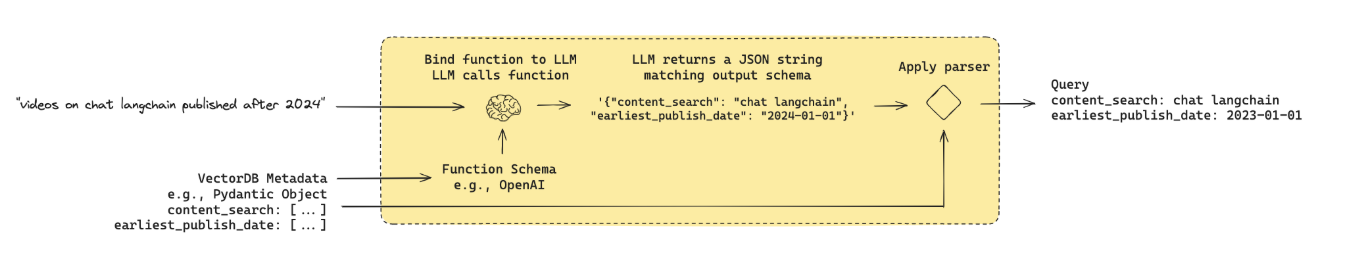

In [22]:
import os
import sqlite3

from typing import Optional
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

conn = sqlite3.connect(":memory:")

cursor = conn.cursor()

cursor.execute("""
CREATE TABLE products (
    id INTEGER PRIMARY KEY,
    name TEXT,
    category TEXT,
    brand TEXT,
    price REAL,
    rating REAL
)
""")

In [23]:
products = [
    ("Sony WH-1000XM5", "headphones", "Sony", 299, 4.8),
    ("JBL Tune 770NC", "headphones", "JBL", 99, 4.4),
    ("Apple AirPods Max", "headphones", "Apple", 549, 4.7),
    ("Boat Rockerz 550", "headphones", "Boat", 49, 4.2),
    ("Samsung Galaxy Buds", "earbuds", "Samsung", 129, 4.5),
    ("Sony WF-1000XM5", "earbuds", "Sony", 249, 4.8),
    ("Dell XPS 13", "laptop", "Dell", 999, 4.7),
    ("MacBook Air M3", "laptop", "Apple", 1299, 4.9),
]

cursor.executemany("""
INSERT INTO products(
    name,
    category,
    brand,
    price,
    rating
)
VALUES (?, ?, ?, ?, ?)
""", products)

conn.commit()

In [24]:
cursor.execute("SELECT * FROM products")

for row in cursor.fetchall():
    print(row)

(1, 'Sony WH-1000XM5', 'headphones', 'Sony', 299.0, 4.8)
(2, 'JBL Tune 770NC', 'headphones', 'JBL', 99.0, 4.4)
(3, 'Apple AirPods Max', 'headphones', 'Apple', 549.0, 4.7)
(4, 'Boat Rockerz 550', 'headphones', 'Boat', 49.0, 4.2)
(5, 'Samsung Galaxy Buds', 'earbuds', 'Samsung', 129.0, 4.5)
(6, 'Sony WF-1000XM5', 'earbuds', 'Sony', 249.0, 4.8)
(7, 'Dell XPS 13', 'laptop', 'Dell', 999.0, 4.7)
(8, 'MacBook Air M3', 'laptop', 'Apple', 1299.0, 4.9)


In [25]:
class ProductSearch(BaseModel):

    content_search: str = Field(
        description="Product category or product type"
    )

    max_price: Optional[float] = Field(
        default=None,
        description="Maximum allowed price"
    )

    min_price: Optional[float] = Field(
        default=None,
        description="Minimum allowed price"
    )

    min_rating: Optional[float] = Field(
        default=None,
        description="Minimum rating"
    )

    brand: Optional[str] = Field(
        default=None,
        description="Brand filter"
    )

In [26]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)

structured_llm = llm.with_structured_output(ProductSearch)
structured_llm

RunnableBinding(bound=ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x000001759235FE50>, default_metadata=(), model_kwargs={}), kwargs={'response_mime_type': 'application/json', 'response_json_schema': {'properties': {'content_search': {'description': 'Product category or product type', 'title': 'Content Search', 'type': 'string'}, 'max_price': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'description': 'Maximum allowed price', 'title': 'Max Price'}, 'min_price': {'anyOf': [{'type': 'number'},

In [27]:
system = """
You are an expert shopping query analyzer.

Convert user shopping questions into structured metadata filters.

Examples:

Input:
headphones under 100 dollars

Output:
content_search = headphones
max_price = 100

Input:
sony headphones with rating above 4.5

Output:
content_search = headphones
brand = Sony
min_rating = 4.5

Return only the structured object.
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}")
    ]
)

query_analyzer = prompt | structured_llm

In [28]:
query = query_analyzer.invoke({
    "question":
    "wireless headphones under 100 dollars with rating above 4.3"
})

print(query)

content_search='wireless headphones' max_price=100.0 min_price=None min_rating=4.3 brand=None


In [ ]:
def retrieve_products(query: ProductSearch):

    sql = """
    SELECT *
    FROM products
    WHERE 1=1
    """

    params = []

    if query.max_price is not None:
        sql += " AND price <= ?"
        params.append(query.max_price)

    if query.min_price is not None:
        sql += " AND price >= ?"
        params.append(query.min_price)

    if query.min_rating is not None:
        sql += " AND rating >= ?"
        params.append(query.min_rating)

    if query.brand is not None:
        sql += " AND brand = ?"
        params.append(query.brand)

    # simple semantic filtering
    if query.content_search:
        sql += """
        AND (
            LOWER(name) LIKE ?
            OR LOWER(category) LIKE ?
        )
        """

        keyword = f"%{query.content_search.lower()}%"

        params.append(keyword)
        params.append(keyword)

    cursor.execute(sql, params)

    return cursor.fetchall()

In [30]:
response_prompt = ChatPromptTemplate.from_template(
"""
You are a helpful shopping assistant.

User Question:
{question}

Structured Query:
{structured_query}

Retrieved Products:
{products}

Recommend the matching products.
If there are multiple products, compare them briefly.
"""
)

In [31]:
final_chain = (

    RunnablePassthrough()

    | RunnableLambda(
        lambda question: {
            "question": question,
            "structured_query":
                query_analyzer.invoke(
                    {"question": question}
                )
        }
    )

    | RunnableLambda(
        lambda x: {
            "question": x["question"],
            "structured_query": x["structured_query"],
            "products":
                retrieve_products(
                    x["structured_query"]
                )
        }
    )

    | response_prompt
    | llm
)

In [ ]:
response = final_chain.invoke("show me headphones under 100 dollars with rating above 4.3")

response.content

Structured Query
content_search='products' max_price=None min_price=None min_rating=None brand='Sony'

Retrieved Products
(1, 'Sony WH-1000XM5', 'headphones', 'Sony', 299.0, 4.8)
(6, 'Sony WF-1000XM5', 'earbuds', 'Sony', 249.0, 4.8)
